In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# Загружаем данные

In [1]:
import statsmodels.api as sm
df = sm.datasets.get_rdataset("Boston", "MASS").data
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [38]:
df.shape

(506, 14)

- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per \$10,000
- PTRATIO - pupil-teacher ratio by town
- BLACK - the proportion of blacks by town
- LSTAT - \% lower status of the population
- MEDV - Median value of owner-occupied homes in $1000's

In [3]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

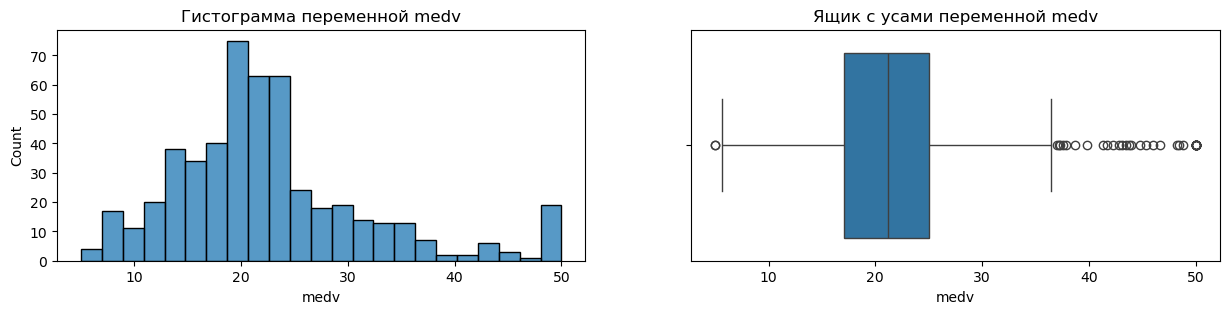

In [4]:
visualize_distribution(df, variable = "medv")

# 1. Подготовка данных

In [5]:
# Убираем выбросы по правилу +/- 2 стандартных отклонения, z-score
df = df[np.abs((df['medv']-df['medv'].mean())/df['medv'].std())<=2]

In [6]:
df.shape

(475, 14)

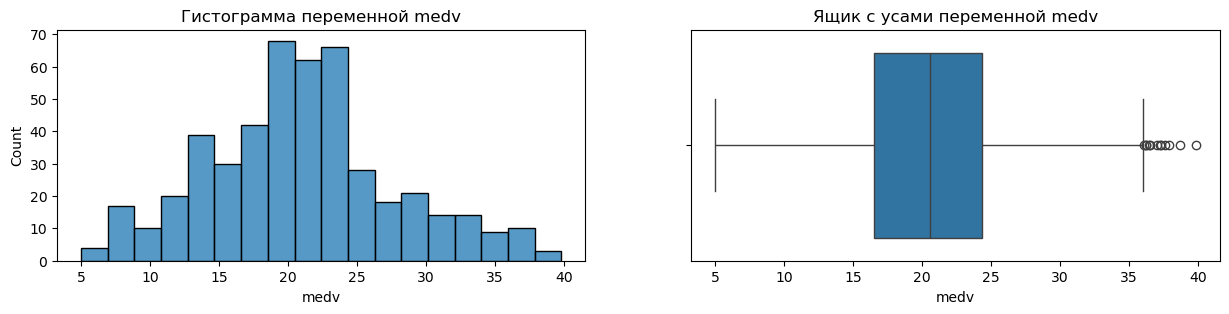

In [7]:
visualize_distribution(df, variable = "medv")

In [8]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Попытаемся предсказать медианную цену недвижимости на основе других переменных

medv - целевая переменная

# 2. Изучаем связь целевой переменной и предикторов

<Figure size 1500x1500 with 0 Axes>

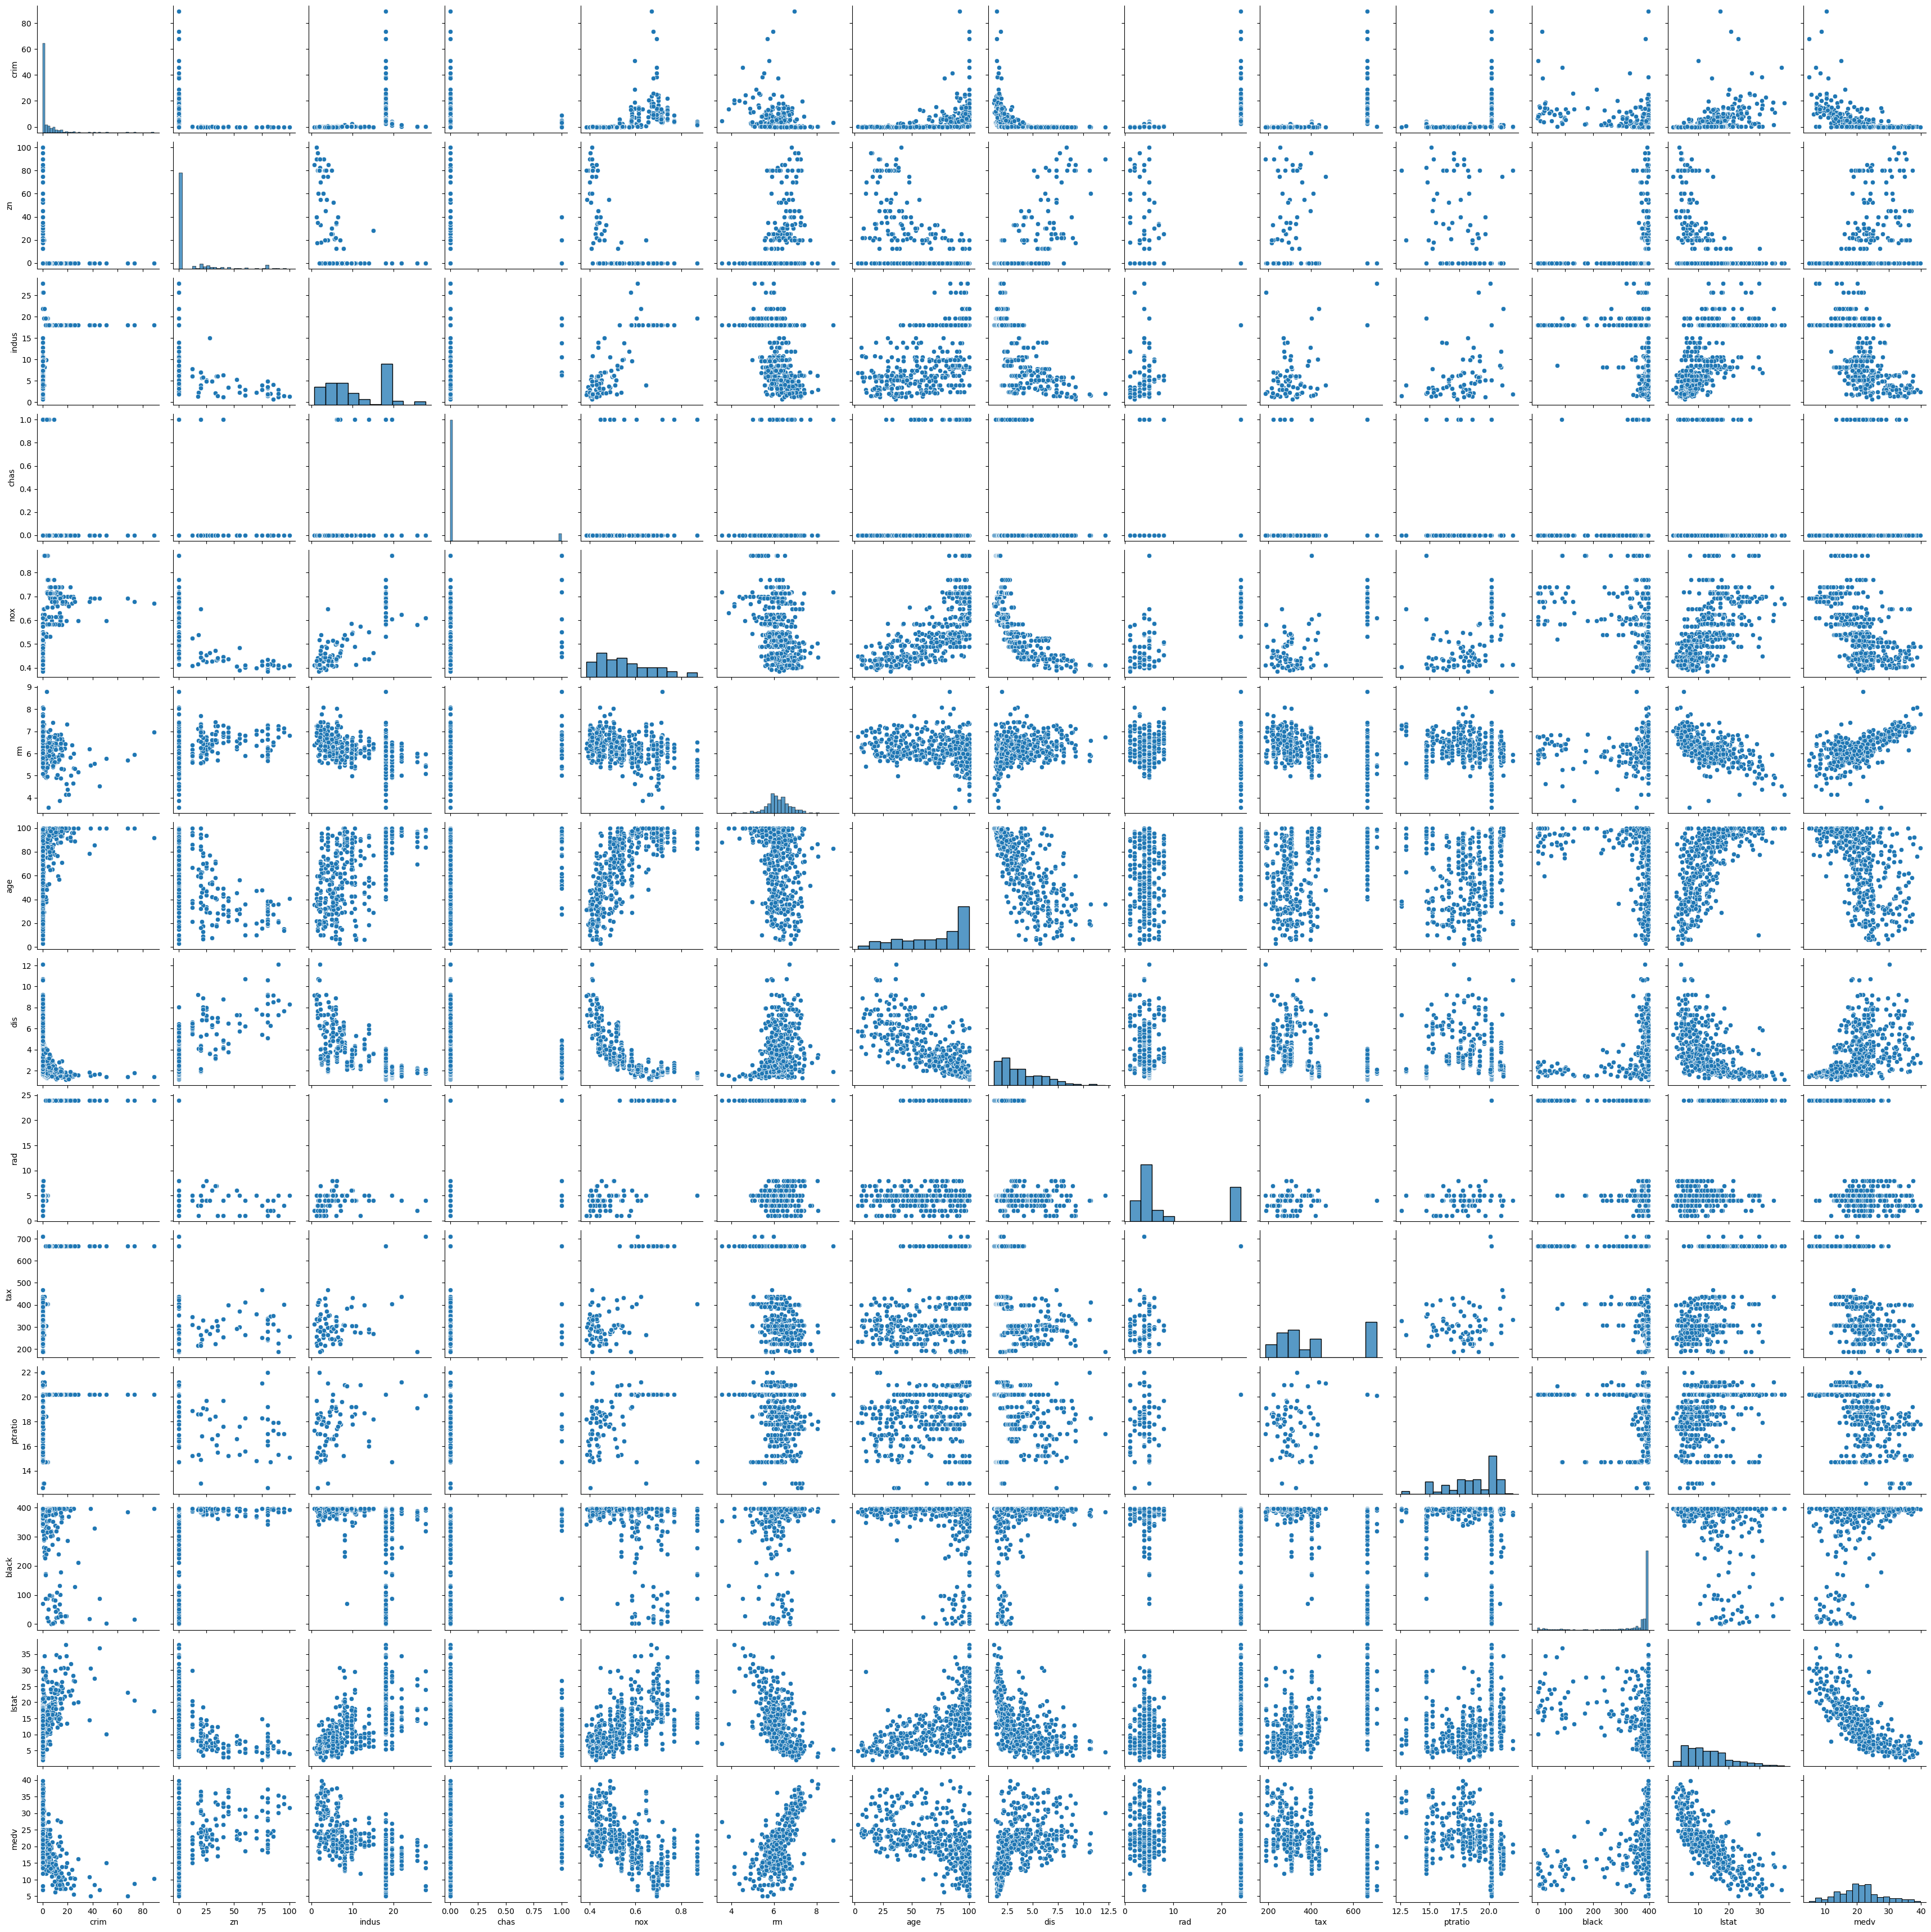

In [9]:
fig = plt.figure(figsize = (15, 15))
sns.pairplot(df)
plt.show()

# 3. Обучим модели линейной регрессии

In [9]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test):
    return model.predict(X_test)

def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

#### Простая модель $medv_i = w_0 + w_1 \cdot lstat_i$

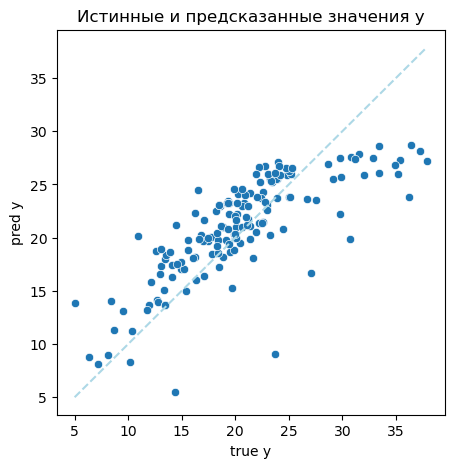

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  16.836481435133805
RMSE:  4.103228172443473
MAE:  3.120573623787427
MAPE:  0.1689399094565656
R2:  0.6012562804702185


In [10]:
target_col = ['medv']
features_col = ['lstat']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Модель $medv_i = w_0 + w_1 \cdot lstat_i + w_2 \cdot rm_i$

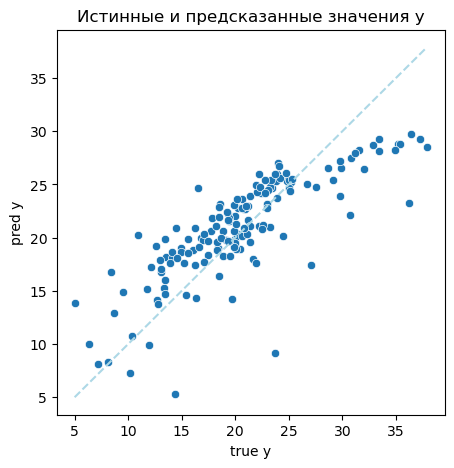

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  15.237929587269898
RMSE:  3.903579074038324
MAE:  2.977801779202345
MAPE:  0.17006254840528004
R2:  0.6391152899155251


In [11]:
target_col = ['medv']
features_col = ['lstat', 'rm']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Модель $medv_i = w_0 + w_1 \cdot lstat_i + w_2 \cdot rm_i + w_3 \cdot crim_i + w_4 \cdot indus_i$

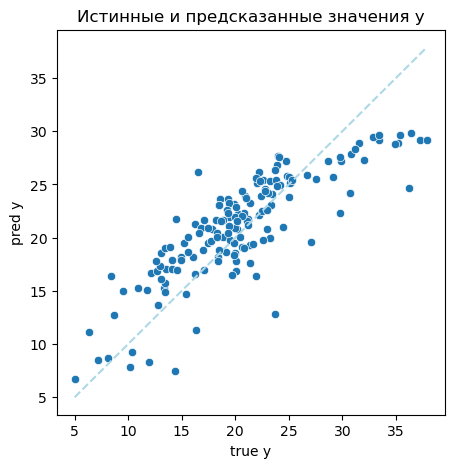

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  13.60717952676659
RMSE:  3.688791065751297
MAE:  2.9793340288492907
MAPE:  0.16491132520213894
R2:  0.6777368598233315


In [12]:
target_col = ['medv']
features_col = ['lstat', 'rm', 'crim', 'indus']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

# 4. Интерпретируем полученную модель

In [13]:
w0 = model.intercept_   # Забираем intercept
weights = model.coef_   # Забираем веса модели
features = model.feature_names_in_
pd.Series(dict(zip(features.tolist()+['intercept'], weights[0].tolist()+[w0[0]])))

lstat        -0.422345
rm            2.513999
crim         -0.119253
indus        -0.190270
intercept    13.703514
dtype: float64

$\hat{medv}_i = 13.7035 - 0.4223 \cdot lstat_i + 2.5140 \cdot rm_i - 0.1193 \cdot crim_i - 0.1903 \cdot indus_i$

При прочих равных ...
1) В районах с более высоким процентом бедного населения, цены на недвижимость ниже
2) Недвижимость с большим количеством комнат стоит дороже
3) В районах с более высоким уровнем преступности, цены на недвижимость ниже
4) В районах с более высокой долей земли, занятой под промышленность, цены на недвижимость ниже

# 5. Повышаем качество модели

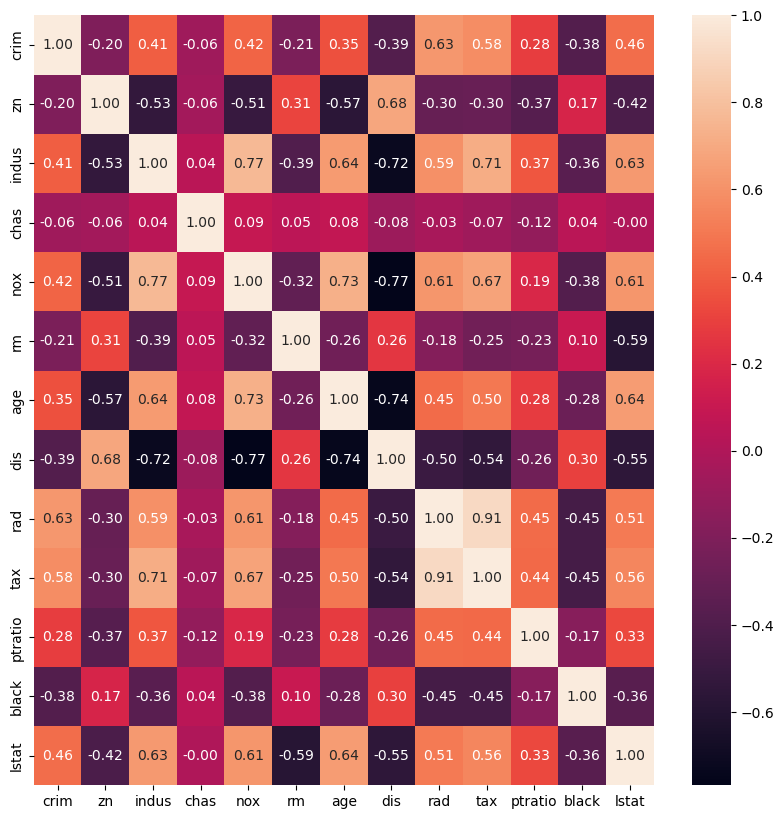

In [15]:
# Проверям переменные на мультиколлинеарность и убираем те, которые тесно скоррелированы
features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']
fig, ax = plt.subplots(1,1, figsize = (10,10))
sns.heatmap(df[features_col].corr(), annot = True, fmt='.2f')
plt.show()

Переменная dis тесно (отрицательно) связана с тремя другими переменными: indus, nox, age

Нет смысла в регрессии использовать все 4 переменные. Можно оставить только dis

rad и tax имеют тесную положительную связь - оставляем только rad

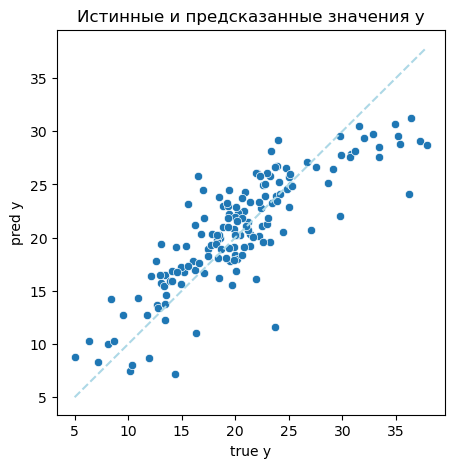

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  12.381652160785448
RMSE:  3.51875718980231
MAE:  2.7068155701448804
MAPE:  0.14742233390989934
R2:  0.7067614123807984


In [16]:
target_col = ['medv']
features_col = ['crim', 'zn', 'chas', 'rm', 'dis', 'rad', 'ptratio', 'black', 'lstat']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

# 6. Примеры форм зависимостей между Х и Y

**Линейная зависимость**

In [17]:
def draw_scatteplot(df, x, y, xlab, ylab, y_pred = None):
    data = df.copy()
    plt.figure(figsize = (15,5))
    sns.scatterplot(x = x, y = y, data = data)
    if y_pred is not None:
        data["y_pred"] = y_pred
        sns.lineplot(x = x, y = "y_pred", data = data, c = 'forestgreen')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

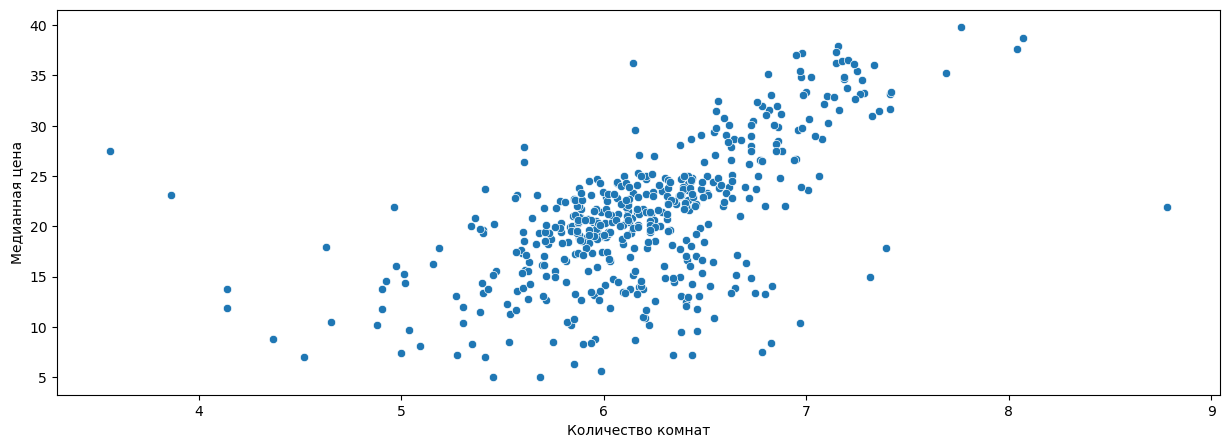

In [18]:
draw_scatteplot(df, x = "rm", y = "medv", xlab = "Количество комнат", ylab = "Медианная цена")

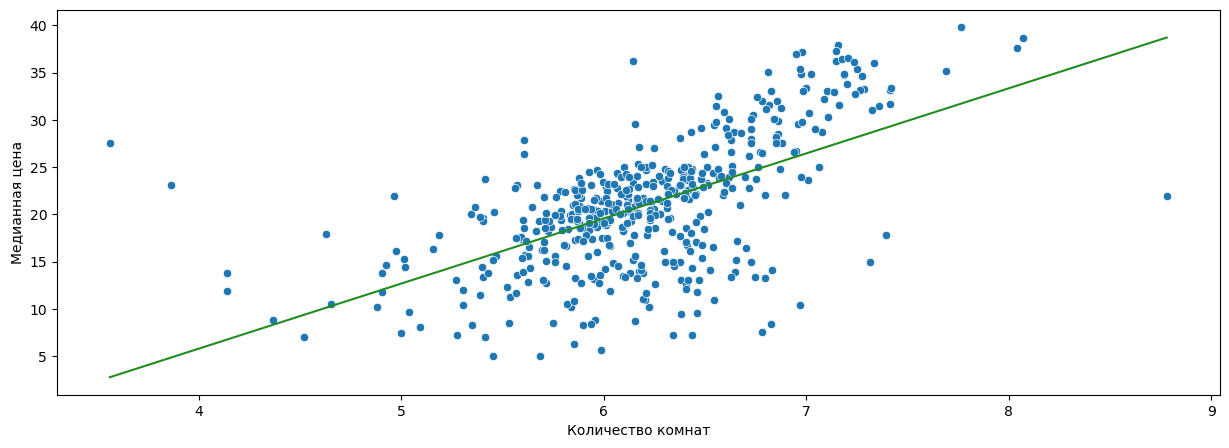

In [19]:
target_col = ['medv']
features_col = ['rm']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "rm", y = "medv", xlab = "Количество комнат", ylab = "Медианная цена", y_pred = y_pred)

**Логарифмическая зависимость**

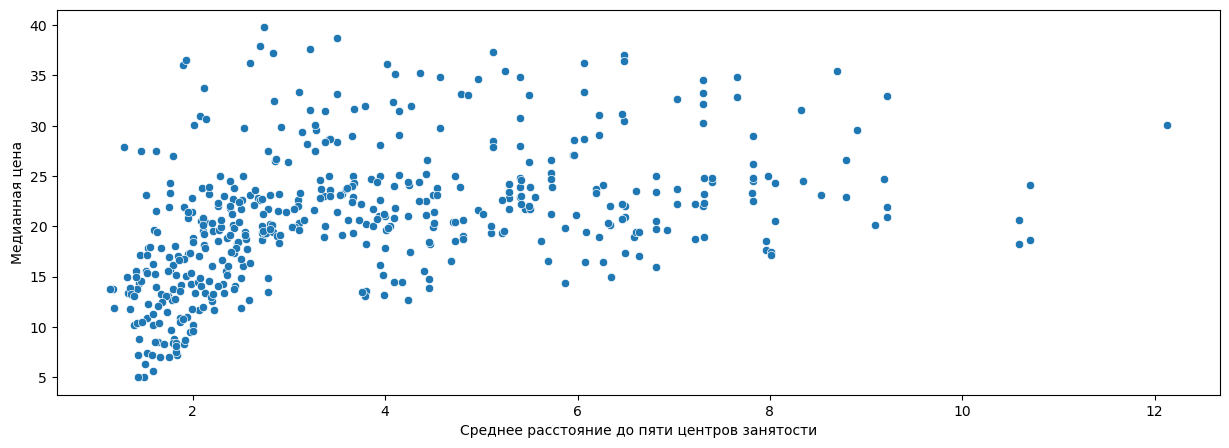

In [20]:
draw_scatteplot(df, x = "dis", y = "medv", xlab = "Среднее расстояние до пяти центров занятости", ylab = "Медианная цена")

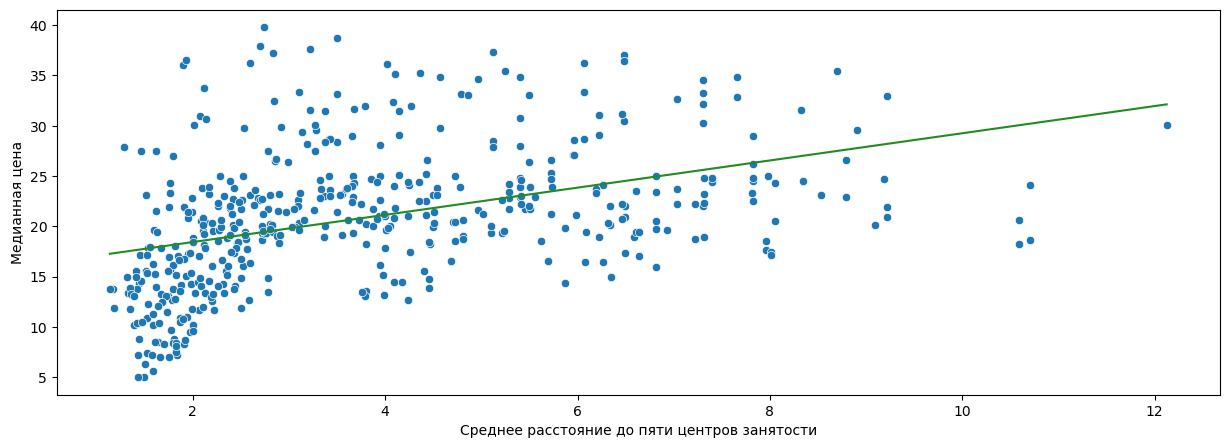

In [21]:
target_col = ['medv']
features_col = ['dis']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "dis", y = "medv", xlab = "Среднее расстояние до пяти центров занятости", ylab = "Медианная цена", y_pred = y_pred)

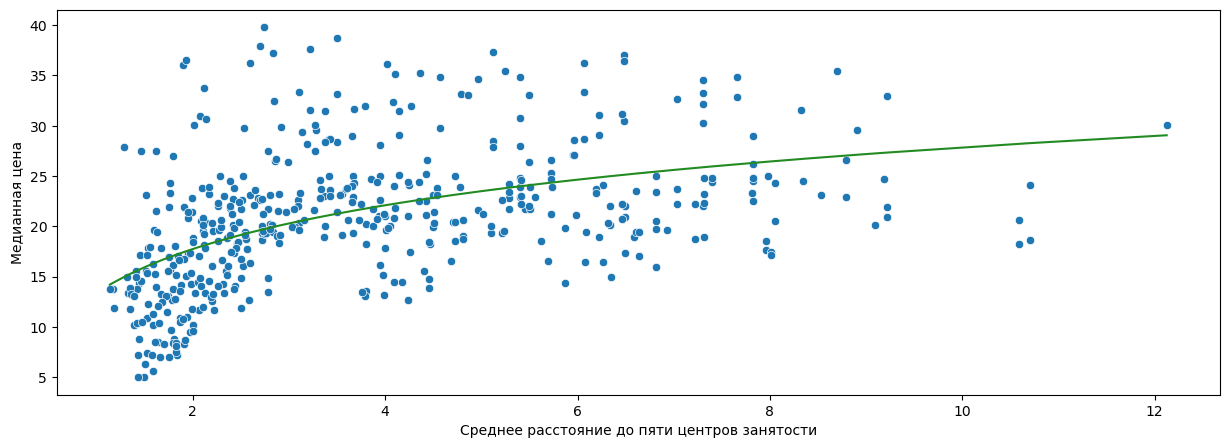

In [22]:
df["log_dis"] = np.log(df["dis"]) # Трансформируем переменную
target_col = ['medv']
features_col = ['log_dis']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "dis", y = "medv", xlab = "Среднее расстояние до пяти центров занятости", ylab = "Медианная цена", y_pred = y_pred)

**Полиномиальная зависимость**

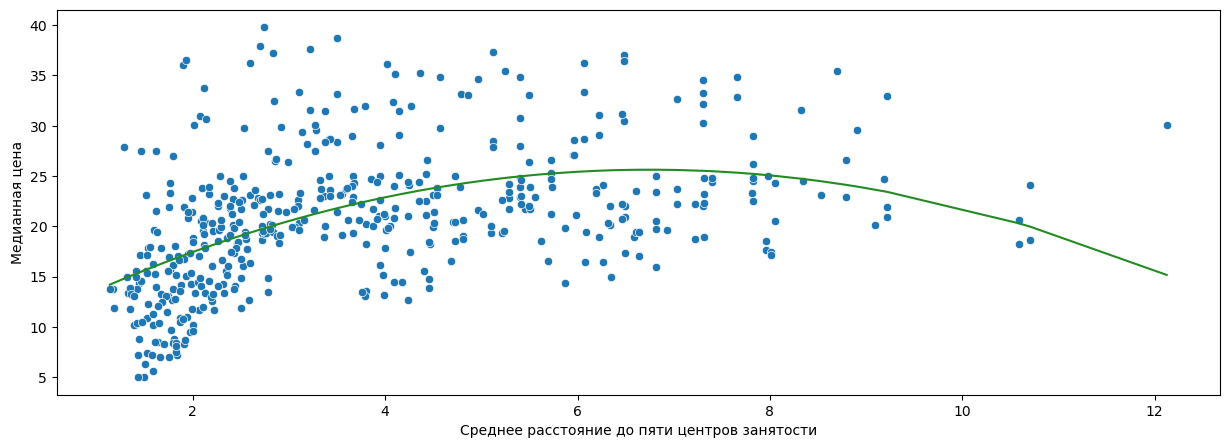

In [23]:
df["dis2"] = df["dis"]**2 # Трансформируем переменную
target_col = ['medv']
features_col = ["dis", "dis2"]
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "dis", y = "medv", xlab = "Среднее расстояние до пяти центров занятости", ylab = "Медианная цена", y_pred = y_pred)

**Гипербола**

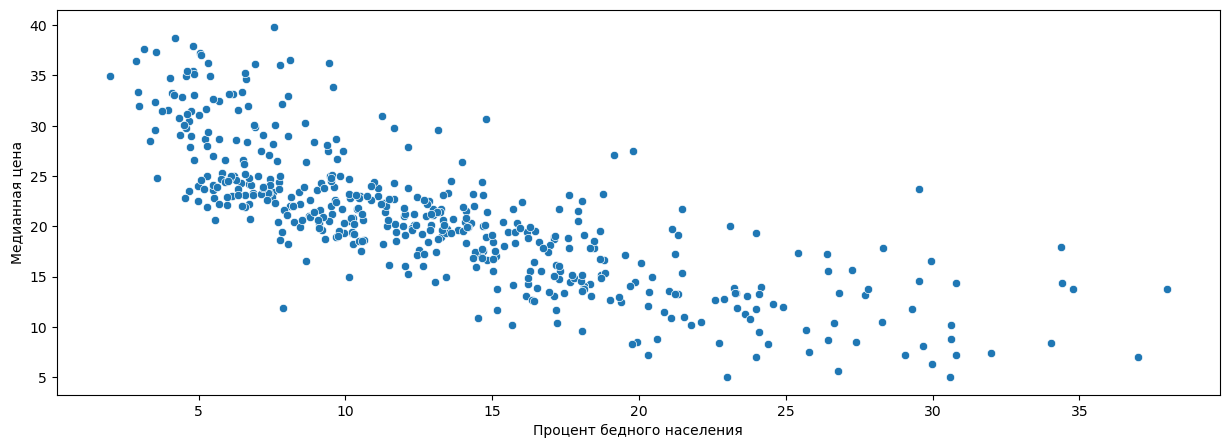

In [24]:
draw_scatteplot(df, x = "lstat", y = "medv", xlab = "Процент бедного населения", ylab = "Медианная цена")

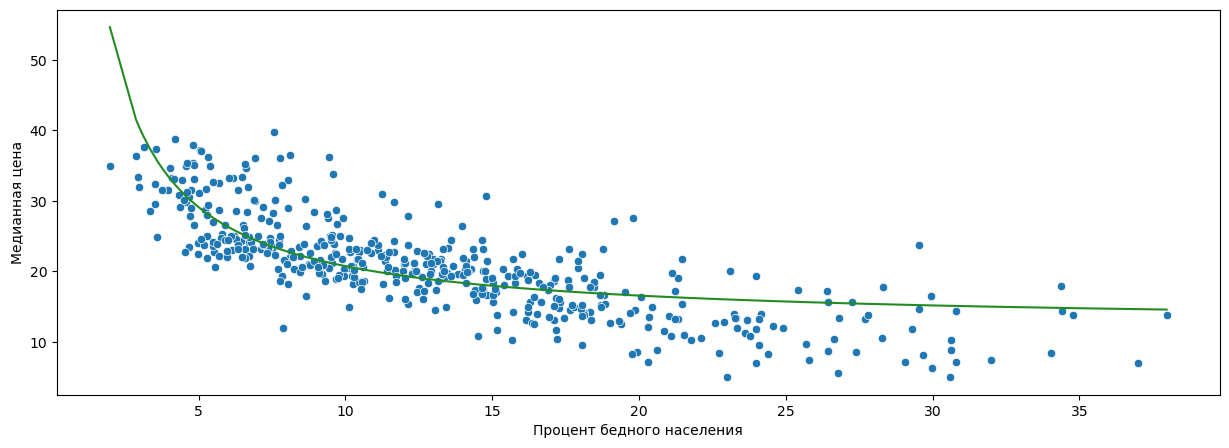

In [25]:
df["lstat_inv"] = df["lstat"]**(-1) # Трансформируем переменную
target_col = ['medv']
features_col = ["lstat_inv"]
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "lstat", y = "medv", xlab = "Процент бедного населения", ylab = "Медианная цена", y_pred = y_pred)

# 7. Еще одна версия модели

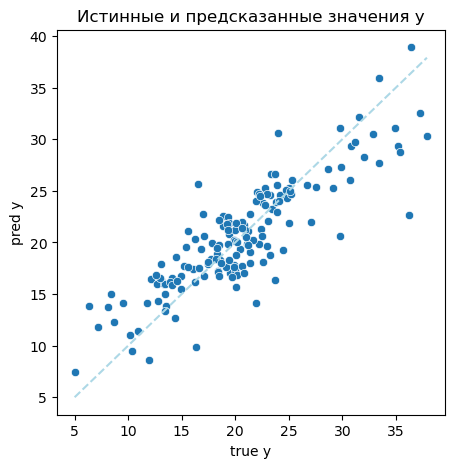

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  11.043304270258153
RMSE:  3.3231467422095813
MAE:  2.537163980630718
MAPE:  0.14416756908554698
R2:  0.7384579291351882


In [26]:
target_col = ['medv']
features_col = ['crim', 'zn', 'chas', 'rm', 'dis', 'dis2', 'rad', 'ptratio', 'black', 'lstat_inv']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

# 8. Проверим устойчивость модели на разных выборках

In [34]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

target_col = ['medv']
features_col = ['crim', 'zn', 'chas', 'rm', 'dis', 'dis2', 'rad', 'ptratio', 'black', 'lstat_inv']
#features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']

for random_state in range(0, 20, 2):
  X_train, X_test, y_train, y_test = train_test_split(df[features_col], df[target_col], test_size = 0.33, random_state = random_state)

  reg = LinearRegression()
  reg.fit(X_train, y_train)
  y_pred = reg.predict(X_test)

  df1 = pd.DataFrame(
      {
          'MSE'  : mean_squared_error(y_test, y_pred),
          'RMSE' : root_mean_squared_error(y_test, y_pred),
          'MAE'  : mean_absolute_error(y_test, y_pred),
          'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
          'R2'   : r2_score(y_test, y_pred)
      },
      index = [random_state]
  )

  df2 = pd.DataFrame(
      index = X_train.columns,
      data = reg.coef_[0],
      columns = [random_state]
  )

  metrics_df = pd.concat([metrics_df, df1])
  coefs_df = pd.concat([coefs_df, df2], axis = 1)

In [35]:
metrics_df

,MSE,RMSE,MAE,MAPE,R2
0,13.226102,3.636771,2.713932,0.159513,0.701658
2,14.186306,3.766471,2.820550,0.157608,0.706934
4,12.598096,3.549380,2.542290,0.139119,0.746506
6,14.276685,3.778450,2.786209,0.168156,0.730218
8,13.608748,3.689004,2.829202,0.151472,0.742274
10,14.375527,3.791507,2.831037,0.145077,0.672249
12,13.317388,3.649300,2.596254,0.164545,0.716885
14,15.137324,3.890671,2.932843,0.158648,0.628297
16,13.768608,3.710607,2.772266,0.153407,0.729954
18,12.526235,3.539242,2.737296,0.155604,0.728265


In [36]:
coefs_df.T

,crim,zn,chas,rm,dis,dis2,rad,ptratio,black,lstat_inv
0,-0.104639,0.001859,0.965047,2.376202,0.527201,-0.082239,-0.006411,-0.695886,0.010229,55.459751
2,-0.099611,0.029384,1.088052,2.503617,1.198288,-0.149123,-0.020479,-0.641714,0.011248,49.803703
4,-0.079458,0.003159,1.680215,3.062771,1.139138,-0.126553,-0.021624,-0.597861,0.009871,46.659515
6,-0.101201,0.003293,0.689911,3.011319,0.928283,-0.100190,-0.019285,-0.578351,0.008157,44.995509
8,-0.132480,0.005962,2.121560,1.969893,0.846306,-0.095221,0.014520,-0.657286,0.006553,53.538026
10,-0.185939,0.028853,1.000624,1.576309,1.419286,-0.173005,0.022976,-0.725360,0.007471,50.229491
12,-0.127113,0.019674,0.591586,2.498876,0.670910,-0.103074,-0.024240,-0.639801,0.009614,54.693078
14,-0.115924,-0.003929,1.105378,2.584465,0.471302,-0.061266,-0.063452,-0.690746,0.010017,51.884070
16,-0.139598,0.003906,0.932392,3.116934,0.643570,-0.082643,0.008083,-0.681817,0.008337,49.211316
18,-0.127917,0.013292,1.210228,2.576413,0.446749,-0.067473,-0.024199,-0.680678,0.009514,52.709871


# 9. Variance inflation factor

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

target_col = ['medv']
#features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']
features_col = ['crim', 'zn', 'indus', 'chas', 'dis', 'rad', 'black', 'lstat']

X = df[features_col]
y = df[target_col]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data.sort_values(by = 'VIF', ascending = False).reset_index(drop = True)

,feature,VIF
0,black,10.292327
1,indus,8.555233
2,dis,8.533208
3,lstat,7.762849
4,rad,4.742567
5,zn,2.367734
6,crim,2.095260
7,chas,1.081176


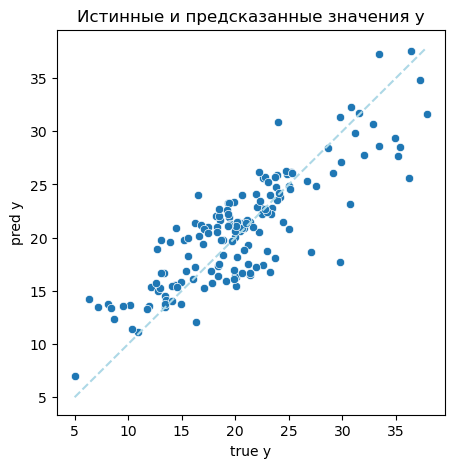

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  12.34410334408257
RMSE:  3.5134176159521044
MAE:  2.7188190979862825
MAPE:  0.1541018829350067
R2:  0.7076506928931033


In [46]:
target_col = ['medv']
features_col = ['crim', 'zn', 'indus', 'chas', 'dis', 'dis2', 'rad', 'black', 'lstat_inv']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

# 10. Lasso регрессия

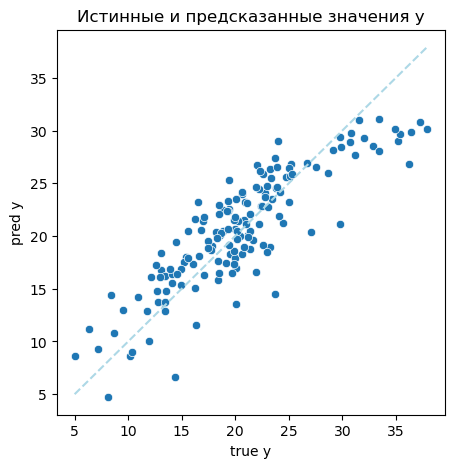

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  10.94789039263873
RMSE:  3.3087596456434745
MAE:  2.6552606484320167
MAPE:  0.1467184799872699
R2:  0.740717646202754


In [52]:
target_col = ['medv']
features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'dis2', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'lstat_inv']

X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)

model = Lasso(alpha = 0.1)
model.fit(X_train, y_train)

y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

In [53]:
pd.DataFrame(
      index = X_train.columns,
      data = model.coef_
).T

,crim,zn,indus,chas,nox,rm,age,dis,dis2,rad,tax,ptratio,black,lstat,lstat_inv
0,-0.089916,0.032072,-0.12262,0.0,-0.0,1.757476,-0.012883,-0.414024,-0.029758,0.195364,-0.013415,-0.641994,0.00449,-0.423639,0.0


**При использовании Lasso и Ridge обязательно масштабирование**

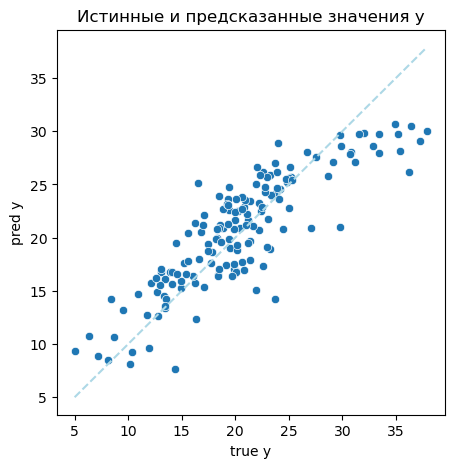

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  11.39953706592586
RMSE:  3.3763200479110185
MAE:  2.689389916637423
MAPE:  0.14543443225019906
R2:  0.7300211550675009


In [54]:
target_col = ['medv']
features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']

X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Lasso(alpha = 0.1)
model.fit(X_train_scaled, y_train)

y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

In [55]:
pd.DataFrame(
      index = X_train.columns,
      data = model.coef_
).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,-0.63533,0.195134,-0.731369,0.269087,-1.108386,1.32131,-0.072511,-1.387178,0.370459,-0.7122,-1.573597,0.26925,-2.870379


# 11. Ridge регрессия

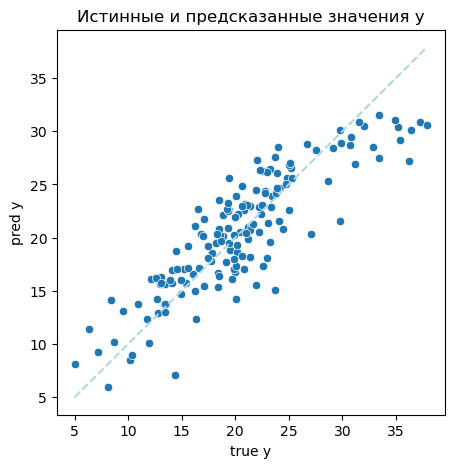

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  10.26412727181107
RMSE:  3.2037676682011558
MAE:  2.5517019270693853
MAPE:  0.13776576595925732
R2:  0.7569114246431331


In [56]:
target_col = ['medv']
features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']

X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=0.1)
model.fit(X_train_scaled, y_train)

y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

In [57]:
pd.DataFrame(
      index = X_train.columns,
      data = model.coef_
).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,-0.918749,0.616509,-0.5807,0.291288,-1.526312,1.262576,-0.264692,-2.202489,1.854061,-1.982507,-1.685765,0.388541,-2.821496


# 12. Elastic Net регрессия

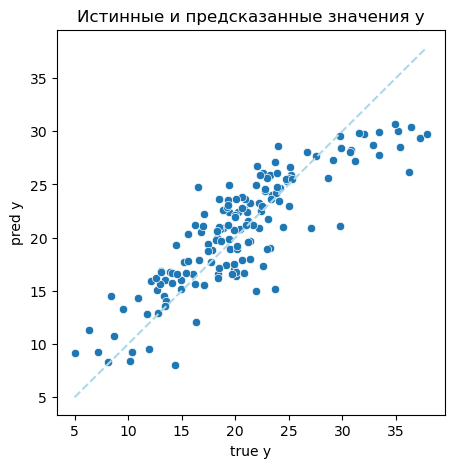

Среднее значение Y:  20.44076433121019
Среднеквадратическое отклонение Y:  6.497985532171287
MSE:  11.108559855595367
RMSE:  3.332950623035896
MAE:  2.66580304683702
MAPE:  0.14469325464106814
R2:  0.7369124604505523


In [58]:
from sklearn.linear_model import ElasticNet
target_col = ['medv']
features_col = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']

X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = ElasticNet(alpha=0.1)
model.fit(X_train_scaled, y_train)

y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

In [59]:
pd.DataFrame(
      index = X_train.columns,
      data = model.coef_
).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,-0.705738,0.263548,-0.74816,0.292613,-1.041796,1.391585,-0.248874,-1.429578,0.553073,-0.911416,-1.519782,0.327511,-2.605517


Что дальше?
1) Применение линейной регрессии для прогноза временных рядов
2) Применение линейной регрессии для оценки связи между переменными (тестирование гипотез)